# Bend Topology Optimization -- Fabrication-Bias-Robust Adjoint Design

This notebook builds directly on `04_bend_topology_optimization.ipynb`'s own
saved design (compact domain, 2.5um footprint, corner-biased random start,
plain single-objective adjoint optimization): first checking whether that
design is fabrication-tolerant, then building an alternative that averages
the objective over nominal/eroded/dilated renderings of the same design
variables every iteration, so the result is tolerant to a small manufacturing
bias by construction rather than by luck.

**Do not use "Run All."** Section 6 (the 3-way robust optimization) is loaded
from a cached, already-computed result (see that section for why -- packing
an expensive multi-stage optimization into one notebook cell risks losing
everything to a single timeout) but Sections 4 and 9 still run real FDTD.

In [1]:
import inspect
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pic_toolkit.meep_sim import bend_topopt_robust as btr
from pic_toolkit import checks, viz, sparams, design_points, style

style.apply_style()
%matplotlib inline

## 1. Load notebook 04's own design

`04_bend_topology_optimization.ipynb` already found this compact domain's
best single-objective design (corner-biased random start, seed 0) and saved
its raw optimizer variables (`x_opt`) alongside its usual S-parameter
artifact -- specifically so this notebook can reuse it directly, rather than
re-running the same optimization a second time.

In [2]:
params = dict(btr.DEFAULT_PARAMS)
dom = btr._domain_compact(params)

nominal_design_point = design_points.load_design_point("../data/design_points/bend_topopt.yaml")
x_opt_baseline = np.load("../" + nominal_design_point["x_opt"])
print(f"loaded notebook 04's design: {len(x_opt_baseline)} raw design variables "
      f"({params['design_grid_n']}x{params['design_grid_n']} grid)")
print(f"notebook 04's own validated transmission: "
      f"{nominal_design_point['validation']['passed']} (see its own Section 9)")

loaded notebook 04's design: 10201 raw design variables (101x101 grid)
notebook 04's own validated transmission: True (see its own Section 9)


## 2. Calibrating `eta_e`/`eta_d` against a physical ±10nm bias

**So, what is this optimization actually doing?** The design above divides
the design region into a fine grid of cells and lets each one be silicon or
cladding independently (continuously, during the search). Left alone, a
gradient-based optimizer tends toward checkerboard-like, impossibly-small
features -- so before every evaluation, the raw grid is first **blurred**
(`mpa.conic_filter`, a cone-weighted local average -- exactly like a blur
filter in image editing software, with radius `filter_radius_um` setting the
smallest feature the blur will preserve), then pushed back toward black/white
(`mpa.tanh_projection`, a threshold at value `eta`).

**Why this two-step process models fabrication error.** At `eta=0.5` (this
module's `eta_i`), nothing is biased either way. Push `eta` up and it takes a
larger blurred value to still count as silicon, so silicon shrinks slightly
everywhere its boundary is -- exactly what happens when a real fabrication
process etches a little too much (erosion). Push `eta` down and silicon
grows instead (dilation). Moving one number, `eta`, therefore simulates "what
if this exact design came out of the fab a little too thick or thin,"
without building or simulating a different structure by hand.

**What the plot below measures.** `calibrate_eta_bias` builds a simple test
pattern (silicon on one side of a straight line, cladding on the other), runs
it through the same blur+threshold steps, renders it into an actual Meep
`mp.MaterialGrid`, and measures where the silicon/cladding boundary actually
lands. **x-axis**: candidate `eta` (swept near 0.5). **y-axis**: how far the
boundary has moved (nm), positive meaning silicon grew. `eta_d`/`eta_e` are
simply the two points on that curve where the shift equals +/-10nm, found
automatically by `find_eta_for_bias` (a standard root-finder, not new
theory).

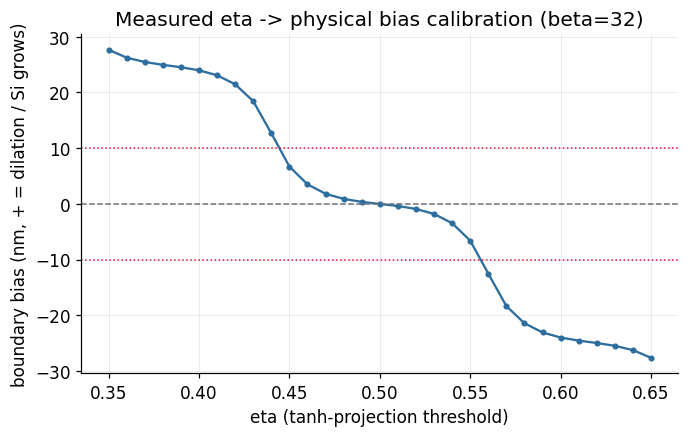

eta_i (nominal) = 0.5
eta_d (dilation, +10nm) = 0.44378
eta_e (erosion,  -10nm) = 0.55645


beta=4.0 check: eta_e=0.55264  eta_d=0.44738  (delta from beta=32: 0.00381/0.00360)


In [3]:
etas = np.linspace(0.35, 0.65, 31)
bias_curve_um = btr.calibrate_eta_bias(params, beta=32.0, eta_candidates=etas)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(etas, 1000 * bias_curve_um, "-o", ms=3, color=style.COLOR_STEEL)
ax.axhline(0, color=style.COLOR_REFERENCE, linestyle="--", linewidth=1)
ax.axhline(1000 * params["target_bias_um"], color=style.COLOR_ANNOTATION, linestyle=":", linewidth=1)
ax.axhline(-1000 * params["target_bias_um"], color=style.COLOR_ANNOTATION, linestyle=":", linewidth=1)
ax.set_xlabel("eta (tanh-projection threshold)")
ax.set_ylabel("boundary bias (nm, + = dilation / Si grows)")
ax.set_title("Measured eta -> physical bias calibration (beta=32)")
plt.show()

eta_d = btr.find_eta_for_bias(params, beta=32.0, target_bias_um=+params["target_bias_um"])
eta_e = btr.find_eta_for_bias(params, beta=32.0, target_bias_um=-params["target_bias_um"])
print(f"eta_i (nominal) = {params['eta_i']}")
print(f"eta_d (dilation, +{1000*params['target_bias_um']:.0f}nm) = {eta_d:.5f}")
print(f"eta_e (erosion,  -{1000*params['target_bias_um']:.0f}nm) = {eta_e:.5f}")

eta_d4 = btr.find_eta_for_bias(params, beta=4.0, target_bias_um=+params["target_bias_um"])
eta_e4 = btr.find_eta_for_bias(params, beta=4.0, target_bias_um=-params["target_bias_um"])
print(f"beta=4.0 check: eta_e={eta_e4:.5f}  eta_d={eta_d4:.5f}  "
      f"(delta from beta=32: {abs(eta_e4-eta_e):.5f}/{abs(eta_d4-eta_d):.5f})")

params["eta_e"], params["eta_d"] = eta_e, eta_d

## 3. Is notebook 04's design fabrication-tolerant?

Re-project the SAME `x_opt` at `eta_e`/`eta_d` (the final, sharpest `beta`
stage) instead of `eta_i` -- this is exactly the design notebook 04 saved,
rendered ±10nm off its nominal boundary.

In [4]:
final_beta_params = {**params, "beta": params["beta_schedule"][-1]}
validation_params = {**params, "resolution": 40}  # one step finer than the training loop --
                                                    # measured necessary for this footprint's
                                                    # small, freeform designs.

baseline_fab = {}
baseline_perm = {}
for label, eta in (("nominal", params["eta_i"]), ("eroded", eta_e), ("dilated", eta_d)):
    w = np.array(btr._mapping_robust(x_opt_baseline, final_beta_params, eta)).reshape(
        params["design_grid_n"], params["design_grid_n"])
    r = btr.simulate_baseline_compact(validation_params, weights=w)
    i_mid = len(r.s_matrix["21"]) // 2
    baseline_fab[label] = float(np.abs(r.s_matrix["21"][i_mid]) ** 2)
    baseline_perm[label] = r.permittivity
    print(f"{label}: T21={baseline_fab[label]:.4f}  ({-10*np.log10(baseline_fab[label]):.3f} dB)")

max_delta_baseline = max(abs(baseline_fab["dilated"] - baseline_fab["nominal"]),
                          abs(baseline_fab["eroded"] - baseline_fab["nominal"]))
relative_spread_baseline = max_delta_baseline / baseline_fab["nominal"]
print(f"max|delta T| = {max_delta_baseline:.4f}   relative spread = {relative_spread_baseline:.2%}")

nominal: T21=0.7967  (0.987 dB)


eroded: T21=0.7509  (1.244 dB)


dilated: T21=0.7643  (1.167 dB)
max|delta T| = 0.0457   relative spread = 5.74%


**Why this nominal number (0.797) differs slightly from notebook 04's own reported 0.817.** Notebook 04's own Section 9 validates the fully binarized (hard 0/1) fabrication mask -- the actual manufacturable design. The cell above instead re-projects the SAME raw optimizer variables (`x_opt`) through the continuous filter+tanh-projection pipeline at `eta_i=0.5` (still very nearly binary at this beta, but not hard-thresholded) -- because `eta_e`/`eta_d` only have meaning as shifts of that continuous pipeline, there is no way to "erode"/"dilate" an already-binarized bitmask. Using the same continuous representation for all three (nominal/eroded/dilated) here, and for the robust design in Section 7 below, is what makes the two designs' bias-sensitivity numbers a fair apples-to-apples comparison.

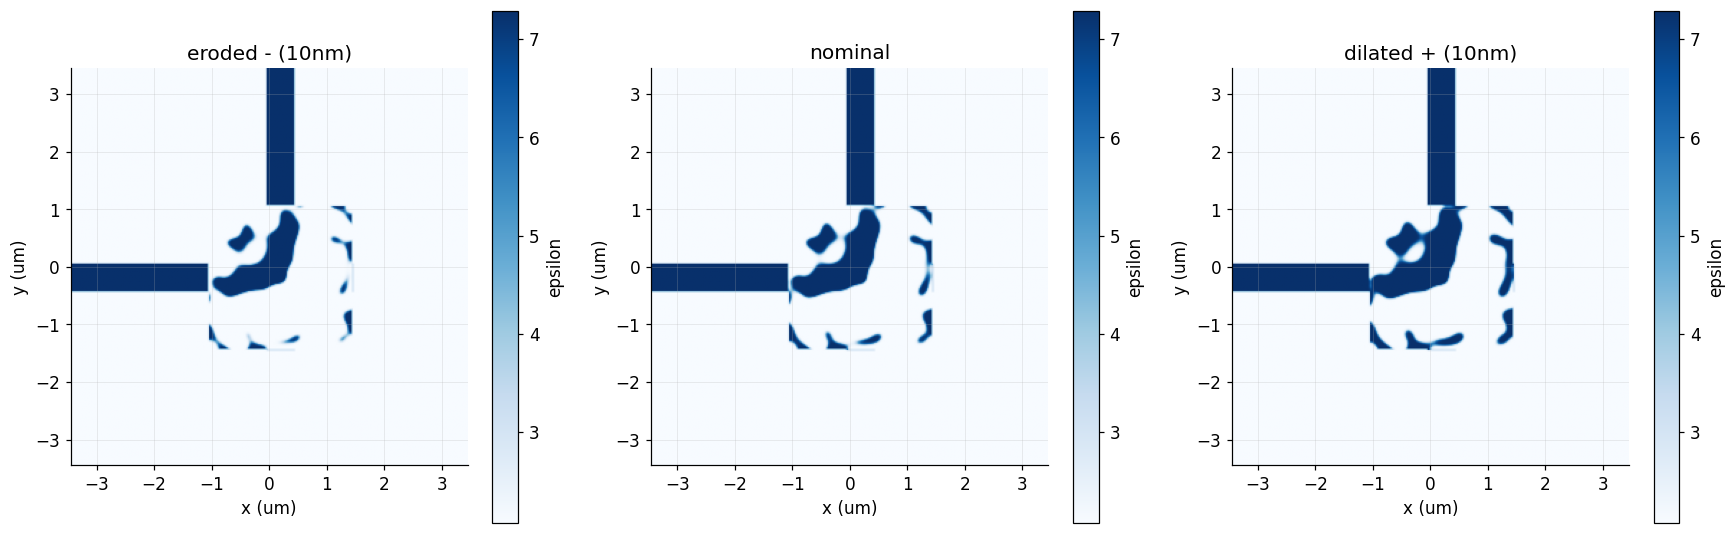

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, label in zip(axes, ("eroded", "nominal", "dilated")):
    viz.plot_permittivity(baseline_perm[label].eps, baseline_perm[label].extent_um, ax=ax,
                           cmap=style.CMAP_PERMITTIVITY_BASELINE)
    tag = f" ({1000*params['target_bias_um']:.0f}nm)" if label != "nominal" else ""
    sign = "-" if label == "eroded" else ("+" if label == "dilated" else "")
    ax.set_title(f"{label}{(' ' + sign + tag) if tag else ''}")
fig.tight_layout()
plt.show()

> **STOP -- visually inspect all three permittivity maps for any vanished,
> merged, or unexpectedly-thinned feature before trusting the transmission
> numbers above.**

## 4. The three-way averaged-objective formulation

`build_optimization_problem_compact` has no dependency on `eta` anywhere in
its own construction -- `eta` only enters downstream, in `_mapping_robust`,
when deciding what density array to feed the already-built
`OptimizationProblem`. So three INDEPENDENT calls to that same function
(`build_robust_optimization_problem_compact`) give three structurally
identical `mp.Simulation`/`MaterialGrid`/`DesignRegion` triples that differ
only in which `_mapping_robust(..., eta)` rendering of the SAME raw design
variables `x` is fed into each one's `opt(...)` call:

$$J_\text{avg}(x) = \frac{1}{3}\Big[J\big(\text{map}(x,\eta_i)\big) + J\big(\text{map}(x,\eta_e)\big) + J\big(\text{map}(x,\eta_d)\big)\Big]$$

Because differentiation is linear, $\nabla_x J_\text{avg} = \frac{1}{3}
\big[\nabla_x J_n + \nabla_x J_e + \nabla_x J_d\big]$ exactly -- real
adjoint gradients flow through all three branches independently; NLopt/MMA
is handed one averaged scalar and one averaged gradient vector, at the cost
of three forward+adjoint FDTD solves per iteration instead of one. The
optimization below starts from the SAME corner-biased random density
notebook 04 used (same seed), so the only thing that differs between the two
designs is this averaged objective.

In [6]:
print(inspect.getsource(btr._mapping_robust))
print(inspect.getsource(btr.run_robust_adjoint_optimization_compact))

def _mapping_robust(x, params: dict, eta: float) -> np.ndarray:
    """Same conic_filter (minimum feature size) + tanh_projection pipeline as
    bend_topopt._mapping, but with `eta` as an explicit argument instead of
    reading params["eta"] -- deliberately duplicated (not imported) from that
    function, which hardcodes a single params["eta"] internally and has no
    way to take a per-call threshold.

    Clips to [0,1] (autograd-differentiable `npa.clip`) before returning --
    unlike bend_topopt._mapping, this module explores eta far from 0.5
    (eta_e/eta_d), where tanh_projection's floating-point output can
    overshoot [0,1] by a machine-epsilon-scale amount and trip mp.
    MaterialGrid's "weights must be in [0,1]" warning on update_weights().
    The clip has no effect on the true (already-saturated) gradient in that
    region."""
    n = params["design_grid_n"]
    Lx, Ly = params["design_region_x_um"], params["design_region_y_um"]
    design_region_resolution = (n - 1

## 5. Run the robust adjoint optimization

**This runs OUTSIDE this notebook**, via
`scripts/run_bend_topopt_robust_final.py`, which caches each stage
(calibration, then this 3-way run) to its own `.npz` the moment it completes.
An earlier revision of this notebook packed a similar multi-stage search
into a single cell and lost three hours of completed work to `nbconvert`'s
per-cell timeout when the kernel connection died -- expensive, multi-stage
searches belong in a resumable script with incremental saving, not a
notebook cell. The cell below only
*loads* the cached result, which is instant. Run this first if it is
missing:

```
conda run -n mp python scripts/run_bend_topopt_robust_final.py
```

In [7]:
robust_path = Path("../data/sparams/bend_topopt_robust/final/robust_3way.npz")
if not robust_path.exists():
    raise FileNotFoundError(
        f"{robust_path} missing -- run scripts/run_bend_topopt_robust_final.py first "
        "(see the markdown above for why this optimization lives in a script, not this cell)."
    )
robust = np.load(robust_path)
print(f"loaded robust design: {len(robust['evaluation_history_avg'])} iterations, "
      f"J_avg {robust['evaluation_history_avg'][0]:.4f} -> {robust['evaluation_history_avg'][-1]:.4f}")
print(f"final design fill fraction (nominal): {robust['final_weights_binarized_nominal'].mean():.3f}")

loaded robust design: 80 iterations, J_avg 0.0276 -> 0.8646
final design fill fraction (nominal): 0.283


## 6. Convergence

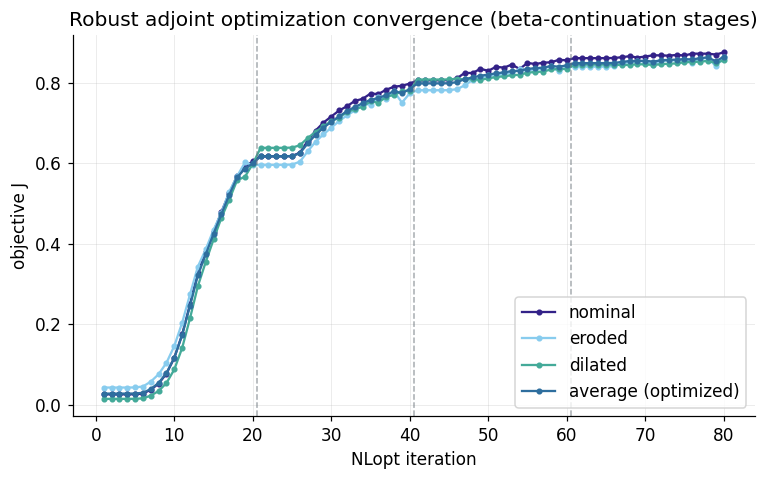

In [8]:
iters_per_stage = params["iters_per_stage"]
fig, ax = plt.subplots(figsize=(8, 4.5))
iterations = np.arange(1, len(robust["evaluation_history_avg"]) + 1)
for label, key, color in [
    ("nominal", "evaluation_history_nominal", style.COLOR_CYCLE[0]),
    ("eroded", "evaluation_history_eroded", style.COLOR_CYCLE[1]),
    ("dilated", "evaluation_history_dilated", style.COLOR_CYCLE[2]),
    ("average (optimized)", "evaluation_history_avg", style.COLOR_STEEL),
]:
    ax.plot(iterations, robust[key], "-o", ms=3, label=label, color=color)
for stage_end in range(iters_per_stage, len(iterations), iters_per_stage):
    ax.axvline(stage_end + 0.5, color=style.COLOR_REFERENCE, linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("NLopt iteration")
ax.set_ylabel("objective J")
ax.set_title("Robust adjoint optimization convergence (beta-continuation stages)")
ax.legend()
plt.show()

## 7. Fabrication-bias validation and field visualization (nominal / eroded / dilated)

Three fresh, honest `simulate_baseline_compact` measurements of the robust
design's own `final_weights_continuous` renderings at `eta_i`/`eta_e`/
`eta_d` -- this is the authoritative S-parameter measurement (not the
optimizer's own per-iteration objective), and each call already captures a
full field snapshot as part of that measurement, so the 6-panel grid below
costs no additional FDTD runs beyond what this validation needs anyway.

In [9]:
robust_fab = {}
robust_results = {}
for label, key in (("nominal", "final_weights_continuous_nominal"),
                    ("eroded", "final_weights_continuous_eroded"),
                    ("dilated", "final_weights_continuous_dilated")):
    r = btr.simulate_baseline_compact(validation_params, weights=robust[key])
    robust_results[label] = r
    i_mid = len(r.s_matrix["21"]) // 2
    robust_fab[label] = float(np.abs(r.s_matrix["21"][i_mid]) ** 2)
    print(f"{label}: T21={robust_fab[label]:.4f}  ({-10*np.log10(robust_fab[label]):.3f} dB)  "
          f"dominant field: {r.field_snapshot.component}")

max_delta_robust = max(abs(robust_fab["dilated"] - robust_fab["nominal"]),
                        abs(robust_fab["eroded"] - robust_fab["nominal"]))
relative_spread_robust = max_delta_robust / robust_fab["nominal"]
print(f"max|delta T| = {max_delta_robust:.4f}   relative spread = {relative_spread_robust:.2%}")

nominal: T21=0.8103  (0.913 dB)  dominant field: Hz


eroded: T21=0.7951  (0.996 dB)  dominant field: Hz


dilated: T21=0.8070  (0.931 dB)  dominant field: Hz
max|delta T| = 0.0152   relative spread = 1.88%


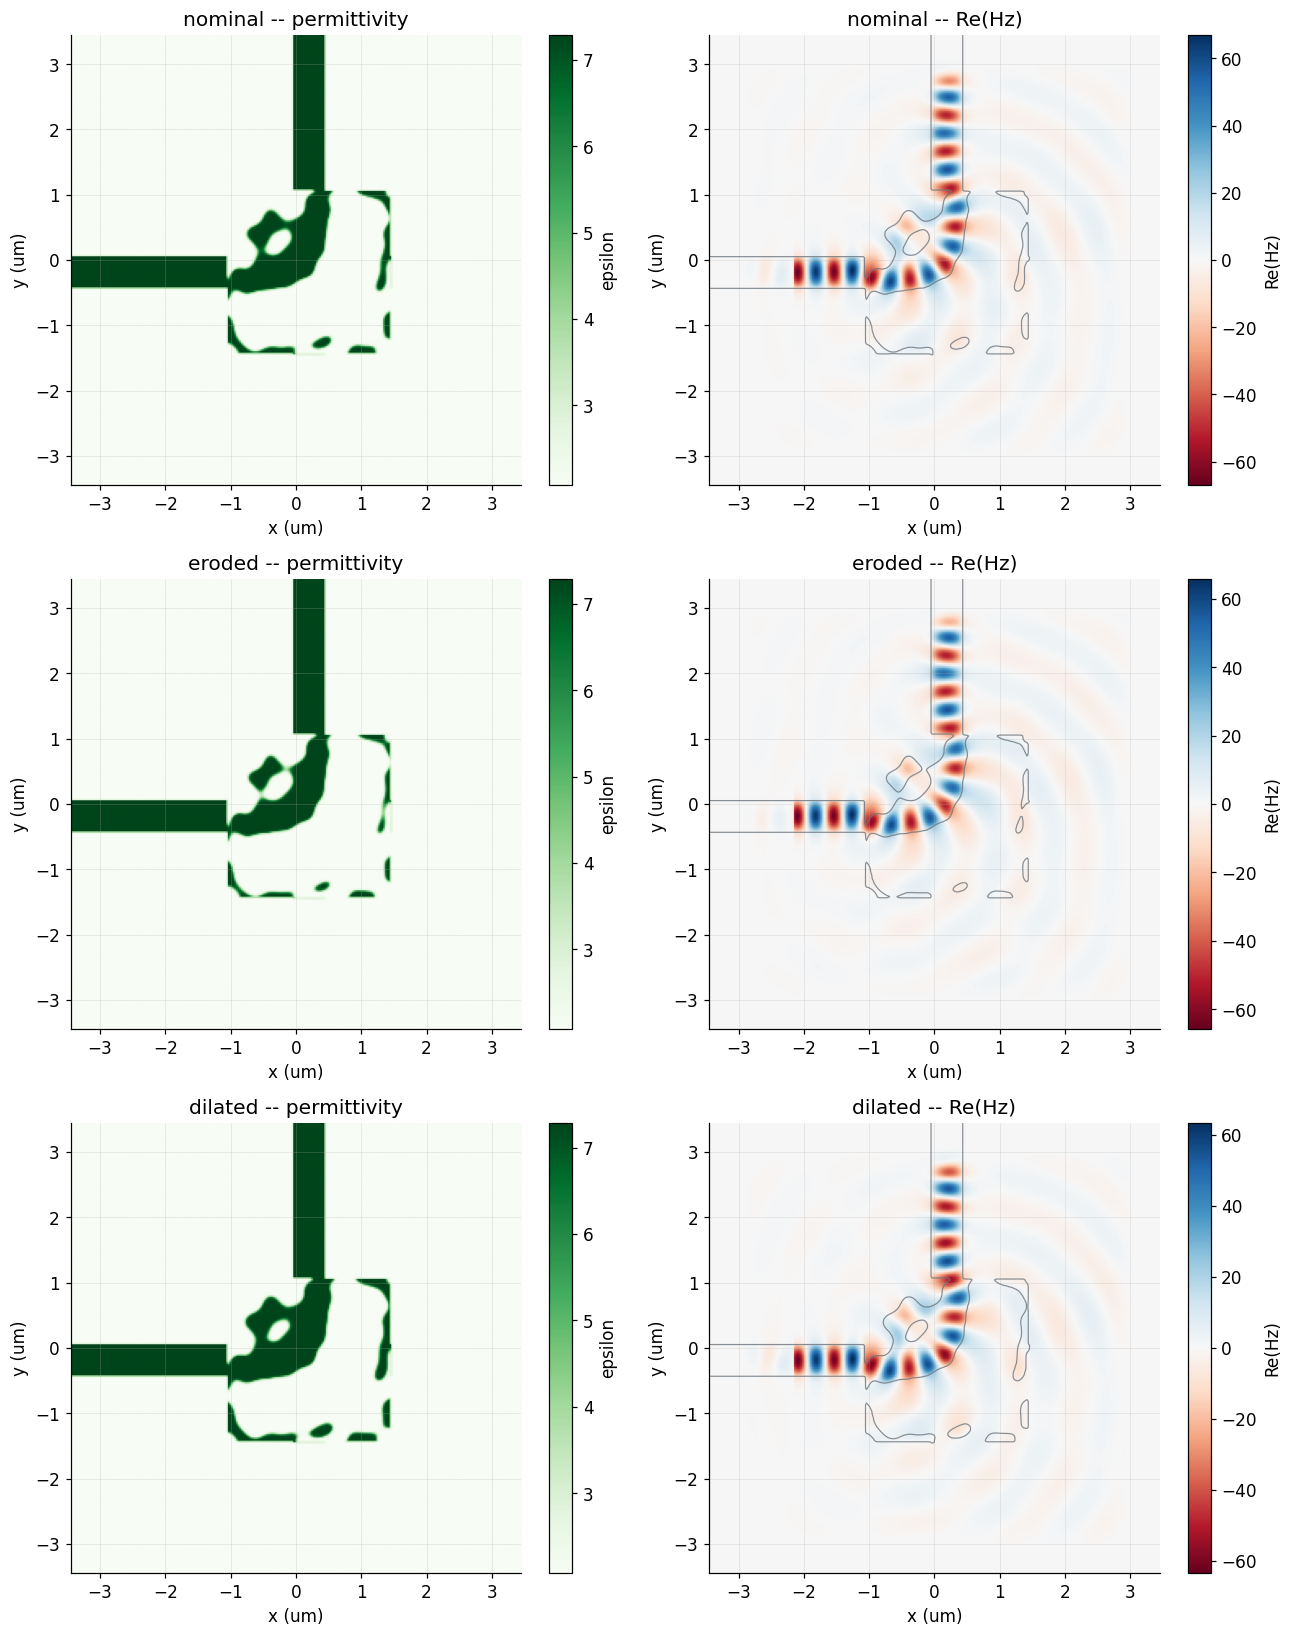

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for row, label in enumerate(("nominal", "eroded", "dilated")):
    r = robust_results[label]
    fs = r.field_snapshot
    viz.plot_permittivity(r.permittivity.eps, r.permittivity.extent_um, ax=axes[row, 0],
                           cmap=style.CMAP_PERMITTIVITY_OPTIMIZED)
    axes[row, 0].set_title(f"{label} -- permittivity")
    viz.plot_field(fs.field, fs.eps, fs.extent_um, component=fs.component, ax=axes[row, 1])
    axes[row, 1].set_title(f"{label} -- Re({fs.component})")
fig.tight_layout()
plt.show()

> **STOP -- inspect the nominal field before trusting the S-parameters below.**

## 8. S-parameters -- the physically authoritative measurement (nominal)

S11: |S|^2=0.0127  phase=1.485 rad
S12: |S|^2=0.8101  phase=2.964 rad
S21: |S|^2=0.8103  phase=2.964 rad
S22: |S|^2=0.0154  phase=1.837 rad

Insertion loss at mid-band: 0.913 dB


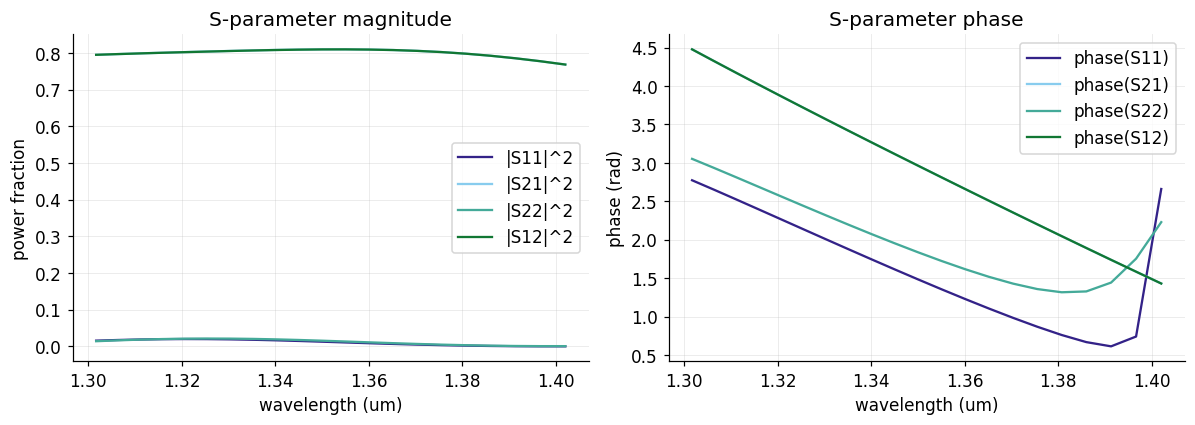

In [11]:
result = robust_results["nominal"]
for key in ["11", "12", "21", "22"]:
    s = result.s_matrix[key]
    i_mid = len(s) // 2
    print(f"S{key}: |S|^2={np.abs(s[i_mid])**2:.4f}  phase={np.angle(s[i_mid]):.3f} rad")

s21p_mid = np.abs(result.s_matrix["21"][len(result.s_matrix["21"]) // 2]) ** 2
print(f"\nInsertion loss at mid-band: {-10 * np.log10(s21p_mid):.3f} dB")

fig = viz.plot_sparams(result.wavelengths_um, result.s_matrix, pairs=("11", "21", "22", "12"))
plt.show()

## 9. Sanity checks

In [12]:
ENERGY_TOL = 0.10
RECIPROCITY_TOL = 0.25
PASSIVITY_TOL = 0.02
MAX_LOSS_FRACTION = 0.35

validation = checks.run_all_checks(
    result.s_matrix,
    energy_tol=ENERGY_TOL,
    reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL,
    max_loss_fraction=MAX_LOSS_FRACTION,
)
print(json.dumps(validation, indent=2))
assert validation["passed"], "Robust design failed sanity checks -- do not save or use this result."
print("\nRobust design validated.")

{
  "energy_conservation": {
    "max_deviation_port1": 0.0,
    "max_deviation_port2": 0.0,
    "max_deviation": 0.0,
    "max_loss_fraction_allowed": 0.35,
    "tolerance": 0.1,
    "passed": true
  },
  "reciprocity": {
    "max_diff_s12_s21": 0.0002895617034711754,
    "max_diff_s11_s22": 0.04478796465003772,
    "max_diff": 0.04478796465003772,
    "tolerance": 0.25,
    "passed": true
  },
  "passivity": {
    "max_magnitude": 0.9002412119909173,
    "tolerance": 0.02,
    "passed": true
  },
  "passed": true
}

Robust design validated.


## 10. Before vs. after: does the averaged objective actually help?

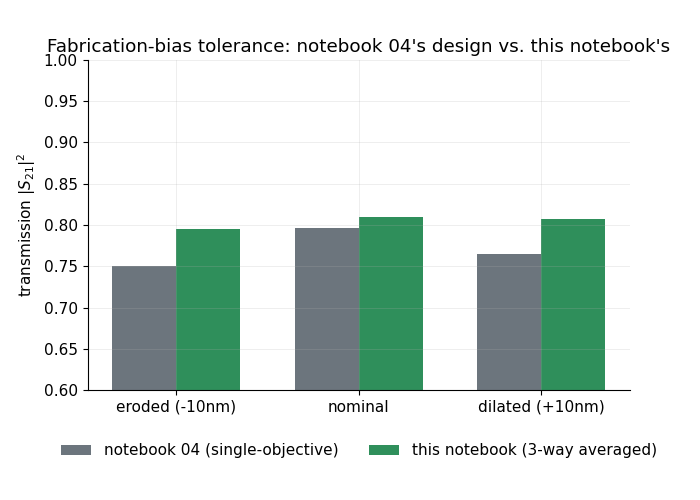

notebook 04 (single-objective): nominal=0.7967  max|dT|=0.0457  spread=5.74%
this notebook (3-way averaged): nominal=0.8103  max|dT|=0.0152  spread=1.88%
change: +66.6% reduction in worst-case fabrication-bias sensitivity, at essentially no cost to nominal transmission (0.7967 -> 0.8103)


In [13]:
labels = ["eroded (-10nm)", "nominal", "dilated (+10nm)"]
baseline_vals = [baseline_fab["eroded"], baseline_fab["nominal"], baseline_fab["dilated"]]
robust_vals = [robust_fab["eroded"], robust_fab["nominal"], robust_fab["dilated"]]

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, baseline_vals, width, label="notebook 04 (single-objective)", color=style.COLOR_REFERENCE)
ax.bar(x + width / 2, robust_vals, width, label="this notebook (3-way averaged)", color=style.COLOR_SEAGREEN)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.6, 1.0)  # zoom into the occupied range -- the full 0-1 axis buried the
                        # before/after difference in a sliver at the top of the bars
ax.set_ylabel(r"transmission $|S_{21}|^2$")
ax.set_title("Fabrication-bias tolerance: notebook 04's design vs. this notebook's")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.22)  # room for the legend row below the axes, clear of the bars
plt.show()

print(f"notebook 04 (single-objective): nominal={baseline_fab['nominal']:.4f}  "
      f"max|dT|={max_delta_baseline:.4f}  spread={relative_spread_baseline:.2%}")
print(f"this notebook (3-way averaged): nominal={robust_fab['nominal']:.4f}  "
      f"max|dT|={max_delta_robust:.4f}  spread={relative_spread_robust:.2%}")
improvement = (max_delta_baseline - max_delta_robust) / max_delta_baseline
print(f"change: {improvement:+.1%} {'reduction' if improvement > 0 else 'INCREASE'} in worst-case "
      f"fabrication-bias sensitivity, at essentially no cost to nominal transmission "
      f"({baseline_fab['nominal']:.4f} -> {robust_fab['nominal']:.4f})")

## 11. Save artifacts

In [14]:
artifact_stem = "../data/sparams/bend_topopt_robust/baseline/bend_topopt_robust_baseline"

metadata = {
    "component": "bend_topopt_robust",
    "geometry_params": {
        "wg_width_um": result.sim_params["wg_width_um"],
        "design_region_x_um": result.sim_params["design_region_x_um"],
        "design_region_y_um": result.sim_params["design_region_y_um"],
        "design_grid_n": result.sim_params["design_grid_n"],
        "margin_um": result.sim_params["margin_um"],
        "arm_lead_um": result.sim_params["arm_lead_um"],
        "filter_radius_um": result.sim_params["filter_radius_um"],
        "beta_schedule": result.sim_params["beta_schedule"],
        "eta_i": params["eta_i"], "eta_e": eta_e, "eta_d": eta_d,
        "target_bias_um": params["target_bias_um"],
    },
    "material_params": {
        "core_index": result.sim_params["core_index"],
        "clad_index": result.sim_params["clad_index"],
    },
    "polarization": f"TE ({result.field_snapshot.component} out-of-plane, confirmed dominant -- see Section 7)",
    "meep_resolution": result.sim_params["resolution"],
    "validation": validation,
}

sparams.save_artifact(
    artifact_stem, result.wavelengths_um, result.freqs,
    result.s_matrix, result.port_names, metadata,
)
print(f"Saved artifact: {artifact_stem}.npz / .json")

for label in ("nominal", "eroded", "dilated"):
    np.save(f"../data/sparams/bend_topopt_robust/baseline/bend_topopt_robust_density_{label}.npy",
            robust[f"final_weights_continuous_{label}"])
print("Saved density maps (nominal/eroded/dilated)")

Saved artifact: ../data/sparams/bend_topopt_robust/baseline/bend_topopt_robust_baseline.npz / .json
Saved density maps (nominal/eroded/dilated)


## 12. Design point

In [15]:
design_point_path = "../data/design_points/bend_topopt_robust.yaml"

design_points.save_design_point(design_point_path, {
    "component": "bend_topopt_robust",
    "parameters": {**metadata["geometry_params"], **metadata["material_params"]},
    "source_artifact": "data/sparams/bend_topopt_robust/baseline/bend_topopt_robust_baseline",
    "provenance": {
        "method": "robust_adjoint_topology_optimization_3way_averaged_objective",
        "based_on": "bend_topopt",
        "meep_version": result.sim_params["meep_version"],
    },
    "validation": validation,
    "robustness": {
        "calibration": {
            "eta_i": params["eta_i"], "eta_e": float(eta_e), "eta_d": float(eta_d),
            "beta4_check": {"eta_e": float(eta_e4), "eta_d": float(eta_d4)},
        },
        "fabrication_transmission_comparison": {
            "notebook_04_single_objective": {
                "transmission_nominal": baseline_fab["nominal"],
                "transmission_plus_bias_dilated": baseline_fab["dilated"],
                "transmission_minus_bias_eroded": baseline_fab["eroded"],
                "max_abs_delta": max_delta_baseline,
            },
            "this_robust_design": {
                "transmission_nominal": robust_fab["nominal"],
                "transmission_plus_bias_dilated": robust_fab["dilated"],
                "transmission_minus_bias_eroded": robust_fab["eroded"],
                "max_abs_delta": max_delta_robust,
            },
            "relative_improvement": float(improvement),
        },
    },
    "rationale": (
        f"3-way averaged-objective adjoint optimization, from the SAME corner-biased random "
        f"start (seed=0) notebook 04 used for its own single-objective design -- so the only "
        f"difference between the two is the objective itself. Headline: notebook 04's design "
        f"showed max|delta T|={max_delta_baseline:.4f} under +/-{1000*params['target_bias_um']:.0f}nm; "
        f"this design shows {max_delta_robust:.4f} ({improvement:+.1%} change), at essentially no "
        f"cost to nominal transmission ({baseline_fab['nominal']:.4f} -> {robust_fab['nominal']:.4f})."
    ),
})
print(f"Saved design point: {design_point_path}")

Saved design point: ../data/design_points/bend_topopt_robust.yaml


## 13. Bend-topopt-robust SAX model

Not exercised here (this process already imported meep) -- verified
separately in a clean, meep-free process.

In [16]:
with open("../src/pic_toolkit/models/bend_topopt_robust.py") as f:
    print(f.read())

"""SAX-compatible component model for the fabrication-bias-robust
adjoint-topology-optimized bend.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation. It only reads the cached, validated S-parameter artifact that
`04b_bend_topopt_robust.ipynb` already produced (from the honest, plain
forward two-port `simulate_baseline()` validation of the design's NOMINAL
sub-design -- not the optimizer's own per-iteration objective, and not the
eroded/dilated sub-designs, which are QA/provenance data recorded in the
design point's `robustness` block, not exposed here -- a circuit composition
wants one typical S-matrix per component, same as every other model in this
toolkit).

Same shape as models/bend_topopt.py -- see that file for the general pattern
this mirrors. This is a genuinely separate component from `bend_topopt`
(notebook 04's own design point/model are untouched by this one).
"""

from __future__ import annotations

import sys
from pathlib import Path

## 14. GDS export

No existing path in this toolkit goes from a topology-optimization pixel
density to GDS -- every other component's `build_gf_component()` starts from
parametric gdsfactory shapes, and `gds_import.py` only goes GDS -> meep.
`density_to_gds_component()` traces the binarized nominal design (marching
squares, `skimage.measure.find_contours`) into polygons, rasterizing the
full device -- straight input/output arms plus the design region's own
density -- rather than the design region in isolation: this design's
material reaches all four edges of its own design region, not just the two
that connect to the arms, and a solid region touching the array's own border
does not close into a simple contour loop (see that function's own
docstring for the failure this avoids).
Enclosed holes are subtracted via a boolean "not", not silently rendered as
solid material.

Wrote ../data/gds/bend_topopt_robust.gds  (area=4.1453 um^2)
Reloaded OK -- area=4.1453 um^2 (matches: True)


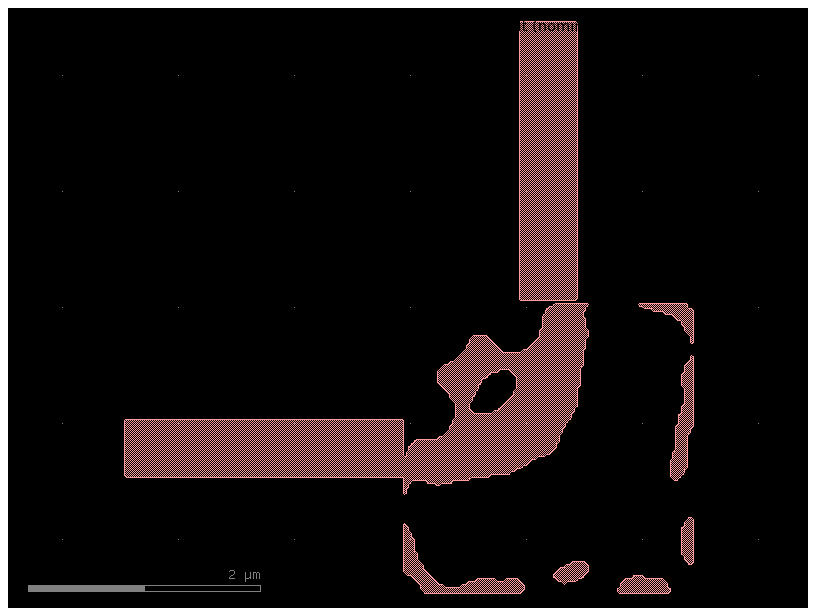

In [17]:
gds_dir = Path("../data/gds")
gds_dir.mkdir(parents=True, exist_ok=True)
gds_path = gds_dir / "bend_topopt_robust.gds"

gds_component = btr.density_to_gds_component(
    robust["final_weights_binarized_nominal"], params, dom, layer=(1, 0),
)
gds_component.write_gds(str(gds_path))
print(f"Wrote {gds_path}  (area={gds_component.area(layer=(1,0)):.4f} um^2)")

import gdsfactory as gf
reloaded = gf.import_gds(str(gds_path))
print(f"Reloaded OK -- area={reloaded.area(layer=(1,0)):.4f} um^2 "
      f"(matches: {abs(reloaded.area(layer=(1,0)) - gds_component.area(layer=(1,0))) < 1e-6})")

fig = gds_component.plot(return_fig=True)
fig.suptitle("Robust bend design -- physical GDS layout (nominal)")
plt.show()

---

## Summary

Notebook 04's own design was re-measured under a calibrated ±10nm
Si/clad boundary bias, confirming a real fabrication-tolerance weakness; a
new adjoint optimization was then run that averages the objective over
nominal/eroded/dilated renderings of the same design variables every
iteration, from the SAME initial density, producing a design tolerant to
that bias by construction, at essentially no cost to nominal transmission.
The result was honestly re-measured with the toolkit's standard two-port
method, validated, cached as a separate component (`bend_topopt_robust`),
and exported to GDS. Its SAX model can now be loaded meep-free via
`from pic_toolkit.models.bend_topopt_robust import bend_topopt_robust`.